# Imports

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

# Loading env variables

In [2]:
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")
base_url = os.getenv("BASE_URL")

# Define LLM

In [12]:
model = ChatOpenAI(api_key=api_key,
                    base_url=base_url,
                    #model="gapgpt-qwen-3.5",
                    model="gpt-5.6-luna",
                    temperature=0.7,
                    max_tokens=1000)

# Define State

In [13]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

# Creating Nodes

In [14]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [15]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

# Define and Compile Graph

In [16]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


# Execute the Graph

In [17]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '# Detailed Blog Outline: **The Rise of AI in India**\n\n## 1. Suggested Title Options\n\n1. **The Rise of AI in India: Opportunities, Challenges, and the Road Ahead**\n2. **How Artificial Intelligence Is Transforming India**\n3. **AI in India: From Digital Public Infrastructure to Global Innovation**\n4. **India’s AI Revolution: Growth, Applications, and Future Potential**\n5. **The Future of Artificial Intelligence in India**\n\n## 2. Suggested Meta Description\n\nExplore the rise of AI in India, including government initiatives, startup innovation, industry applications, challenges, employment trends, and India’s position in the global AI ecosystem.\n\n## 3. Primary SEO Keyword\n\n- Rise of AI in India\n\n## 4. Secondary Keywords\n\n- Artificial intelligence in India  \n- AI development in India  \n- IndiaAI Mission  \n- AI startups in India  \n- AI jobs in India  \n- AI applications in India  \n- Future of AI in India  \n- Generative AI i

In [18]:
print(final_state['outline'])

# Detailed Blog Outline: **The Rise of AI in India**

## 1. Suggested Title Options

1. **The Rise of AI in India: Opportunities, Challenges, and the Road Ahead**
2. **How Artificial Intelligence Is Transforming India**
3. **AI in India: From Digital Public Infrastructure to Global Innovation**
4. **India’s AI Revolution: Growth, Applications, and Future Potential**
5. **The Future of Artificial Intelligence in India**

## 2. Suggested Meta Description

Explore the rise of AI in India, including government initiatives, startup innovation, industry applications, challenges, employment trends, and India’s position in the global AI ecosystem.

## 3. Primary SEO Keyword

- Rise of AI in India

## 4. Secondary Keywords

- Artificial intelligence in India  
- AI development in India  
- IndiaAI Mission  
- AI startups in India  
- AI jobs in India  
- AI applications in India  
- Future of AI in India  
- Generative AI in India  
- Indian AI ecosystem  
- AI technology and digital transforma

In [19]:
print(final_state['content'])

# The Rise of AI in India: Opportunities, Challenges, and the Road Ahead

**Meta Description:** Explore the rise of AI in India, including government initiatives, startup innovation, industry applications, challenges, employment trends, and India’s position in the global AI ecosystem.

**Primary SEO Keyword:** Rise of AI in India

**Secondary Keywords:** Artificial intelligence in India, AI development in India, IndiaAI Mission, AI startups in India, AI jobs in India, AI applications in India, Future of AI in India, Generative AI in India, Indian AI ecosystem, AI technology and digital transformation in India

---

## Introduction: India Enters the AI Era

From voice assistants and fraud detection to precision agriculture and AI-powered public services, artificial intelligence is becoming an important part of India’s digital transformation.

Once confined largely to research laboratories and technology companies, AI now influences everyday activities. It helps banks identify suspicious

# Visualize Graph (Optional)

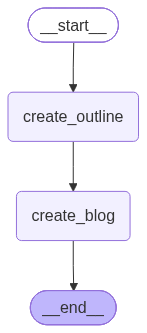

In [20]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())